Saving FAOSTAT_data_en_8-12-2026.xls to FAOSTAT_data_en_8-12-2026 (2).xls
Original dataset:


,Domain,Area,Element,Item,Year,Value
0,Crops and livestock products,United States of America,Area harvested,Wheat,1961,20870000.0
1,Crops and livestock products,United States of America,Yield,Wheat,1961,1607.0
2,Crops and livestock products,United States of America,Area harvested,Wheat,1962,17680000.0
3,Crops and livestock products,United States of America,Yield,Wheat,1962,1680.9
4,Crops and livestock products,United States of America,Area harvested,Wheat,1963,18415008.0



Cleaned dataset:


,Year,Yield,Area_Harvested
0,1961,1607.0,20870000.0
1,1962,1680.9,17680000.0
2,1963,1694.9,18415008.0
3,1964,1734.4,20138000.0
4,1965,1785.3,20056000.0
5,1966,1768.8,20077392.0
6,1967,1737.5,23614288.0
7,1968,1911.6,22162304.0
8,1969,2058.0,19079040.0
9,1970,2086.5,17629488.0




LINEAR REGRESSION REPORT
Model: Yield predicted from Year

Mean Squared Error (MSE)  : 26873.8847
Root Mean Squared Error (RMSE): 163.9326
Mean Absolute Error (MAE) : 134.4277
R² Score                 : 0.8918


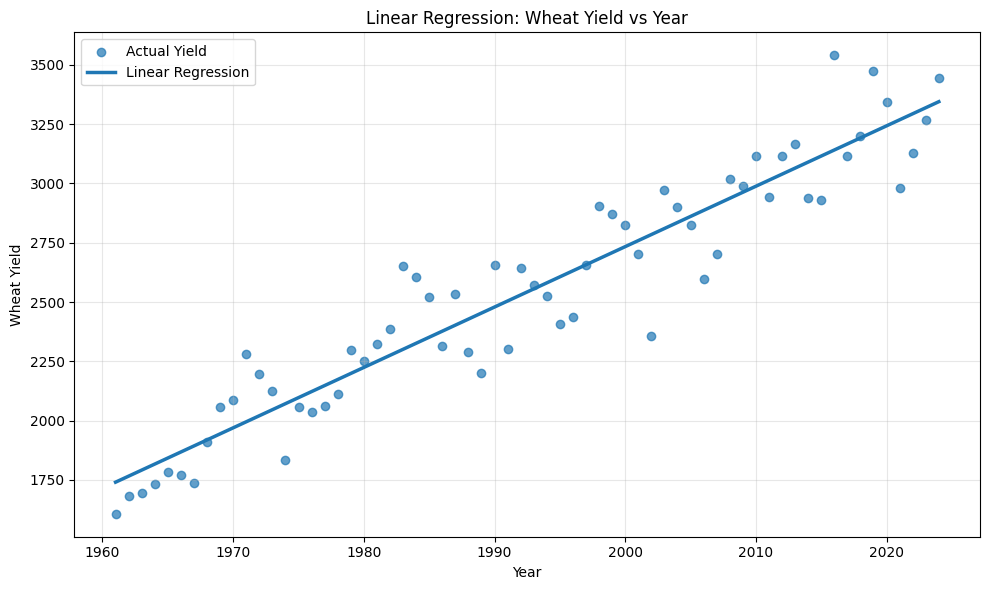



POLYNOMIAL REGRESSION REPORT
Model: Yield predicted from Year
Polynomial Degree: 2

Mean Squared Error (MSE)  : 26642.2068
Root Mean Squared Error (RMSE): 163.2244
Mean Absolute Error (MAE) : 131.9173
R² Score                 : 0.8927


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


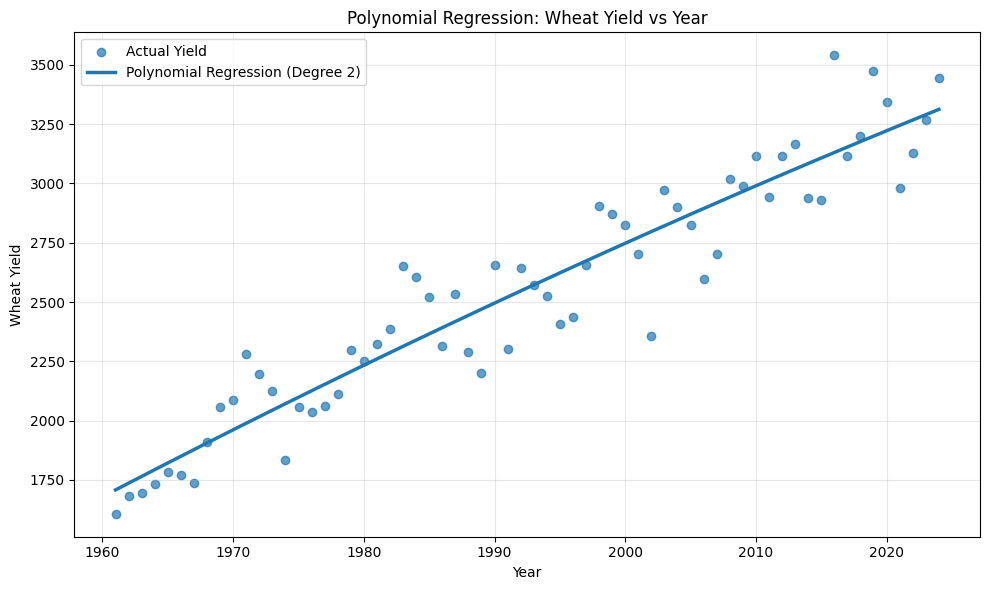



MULTIVARIATE LINEAR REGRESSION REPORT
Model: Yield predicted from Year + Area Harvested

Mean Squared Error (MSE)  : 26645.9940
Root Mean Squared Error (RMSE): 163.2360
Mean Absolute Error (MAE) : 132.1046
R² Score                 : 0.8927

Model Coefficients:
Year coefficient          : 25.910752
Area Harvested coefficient: 0.0000040714
Intercept                 : -49172.814737


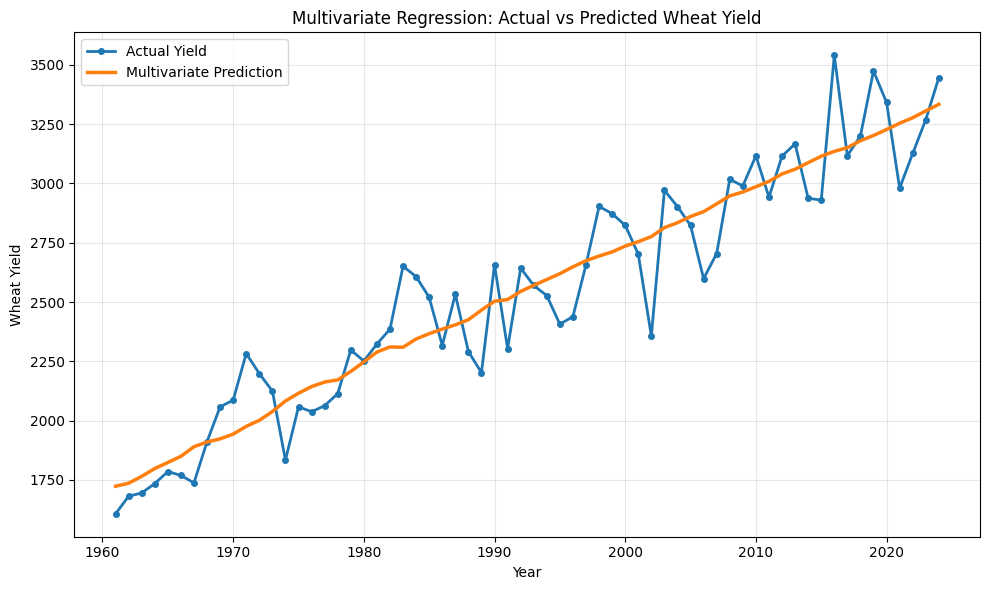



FINAL MODEL PERFORMANCE REPORT

Linear Regression
  MSE  : 26873.8847
  RMSE : 163.9326
  MAE  : 134.4277
  R²   : 0.8918

Polynomial Regression (Degree 2)
  MSE  : 26642.2068
  RMSE : 163.2244
  MAE  : 131.9173
  R²   : 0.8927

Multivariate Linear Regression
  MSE  : 26645.9940
  RMSE : 163.2360
  MAE  : 132.1046
  R²   : 0.8927


END OF REPORT


In [4]:
# ============================================================
# FAOSTAT WHEAT YIELD PREDICTION
# Linear, Polynomial and Multivariate Regression
# ============================================================

# ------------------------------------------------------------
# 1. INSTALL / IMPORT LIBRARIES
# ------------------------------------------------------------

!pip install -q xlrd openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# ------------------------------------------------------------
# 2. UPLOAD FAOSTAT EXCEL FILE
# ------------------------------------------------------------

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

print("Original dataset:")
display(df.head())


# ------------------------------------------------------------
# 3. SELECT REQUIRED COLUMNS
# ------------------------------------------------------------

df = df[
    ['Area', 'Element', 'Item', 'Year', 'Value']
].copy()


# ------------------------------------------------------------
# 4. CLEAN DATA TYPES
# ------------------------------------------------------------

df['Year'] = pd.to_numeric(
    df['Year'],
    errors='coerce'
)

df['Value'] = pd.to_numeric(
    df['Value'],
    errors='coerce'
)

df = df.dropna(
    subset=['Year', 'Value', 'Element']
)


# ------------------------------------------------------------
# 5. SEPARATE YIELD AND AREA HARVESTED
# ------------------------------------------------------------

# FAOSTAT stores both Yield and Area harvested
# inside the same "Value" column.
#
# The "Element" column tells us what each Value represents.
#
# We pivot the data so that:
#
# Area harvested -> Area_Harvested
# Yield          -> Yield

clean_df = df.pivot_table(
    index=['Area', 'Item', 'Year'],
    columns='Element',
    values='Value',
    aggfunc='first'
).reset_index()

clean_df.columns.name = None


# Rename the columns

clean_df = clean_df.rename(
    columns={
        'Area harvested': 'Area_Harvested',
        'Yield': 'Yield'
    }
)


# ------------------------------------------------------------
# 6. KEEP ONLY COMPLETE OBSERVATIONS
# ------------------------------------------------------------

clean_df = clean_df.dropna(
    subset=[
        'Year',
        'Yield',
        'Area_Harvested'
    ]
).copy()

clean_df = clean_df.sort_values(
    'Year'
)

print("\nCleaned dataset:")
display(
    clean_df[
        ['Year', 'Yield', 'Area_Harvested']
    ].head(10)
)


# ------------------------------------------------------------
# 7. PREPARE VARIABLES
# ------------------------------------------------------------

# Target variable
y = clean_df['Yield']


# ============================================================
# MODEL 1: LINEAR REGRESSION
# ============================================================

# Independent variable:
# Year
#
# Dependent variable:
# Yield

X_linear = clean_df[['Year']]

linear_model = LinearRegression()

linear_model.fit(
    X_linear,
    y
)

linear_predictions = linear_model.predict(
    X_linear
)


# ------------------------------------------------------------
# LINEAR REGRESSION METRICS
# ------------------------------------------------------------

linear_mse = mean_squared_error(
    y,
    linear_predictions
)

linear_rmse = np.sqrt(
    linear_mse
)

linear_mae = mean_absolute_error(
    y,
    linear_predictions
)

linear_r2 = r2_score(
    y,
    linear_predictions
)


# ------------------------------------------------------------
# LINEAR REGRESSION REPORT
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("LINEAR REGRESSION REPORT")
print("=" * 60)

print(
    f"Model: Yield predicted from Year"
)

print(
    f"\nMean Squared Error (MSE)  : "
    f"{linear_mse:.4f}"
)

print(
    f"Root Mean Squared Error (RMSE): "
    f"{linear_rmse:.4f}"
)

print(
    f"Mean Absolute Error (MAE) : "
    f"{linear_mae:.4f}"
)

print(
    f"R² Score                 : "
    f"{linear_r2:.4f}"
)


# ------------------------------------------------------------
# LINEAR REGRESSION VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    clean_df['Year'],
    clean_df['Yield'],
    alpha=0.7,
    label='Actual Yield'
)

plt.plot(
    clean_df['Year'],
    linear_predictions,
    linewidth=2.5,
    label='Linear Regression'
)

plt.title(
    'Linear Regression: Wheat Yield vs Year'
)

plt.xlabel('Year')
plt.ylabel('Wheat Yield')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# MODEL 2: POLYNOMIAL REGRESSION
# ============================================================

# Polynomial degree
degree = 2

polynomial_model = Pipeline(
    steps=[
        (
            'polynomial_features',
            PolynomialFeatures(
                degree=degree,
                include_bias=False
            )
        ),
        (
            'linear_regression',
            LinearRegression()
        )
    ]
)


polynomial_model.fit(
    X_linear,
    y
)

polynomial_predictions = polynomial_model.predict(
    X_linear
)


# ------------------------------------------------------------
# POLYNOMIAL REGRESSION METRICS
# ------------------------------------------------------------

poly_mse = mean_squared_error(
    y,
    polynomial_predictions
)

poly_rmse = np.sqrt(
    poly_mse
)

poly_mae = mean_absolute_error(
    y,
    polynomial_predictions
)

poly_r2 = r2_score(
    y,
    polynomial_predictions
)


# ------------------------------------------------------------
# POLYNOMIAL REGRESSION REPORT
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("POLYNOMIAL REGRESSION REPORT")
print("=" * 60)

print(
    f"Model: Yield predicted from Year"
)

print(
    f"Polynomial Degree: {degree}"
)

print(
    f"\nMean Squared Error (MSE)  : "
    f"{poly_mse:.4f}"
)

print(
    f"Root Mean Squared Error (RMSE): "
    f"{poly_rmse:.4f}"
)

print(
    f"Mean Absolute Error (MAE) : "
    f"{poly_mae:.4f}"
)

print(
    f"R² Score                 : "
    f"{poly_r2:.4f}"
)


# ------------------------------------------------------------
# POLYNOMIAL REGRESSION VISUALIZATION
# ------------------------------------------------------------

# Create a smooth sequence of years
smooth_years = np.linspace(
    clean_df['Year'].min(),
    clean_df['Year'].max(),
    300
).reshape(-1, 1)


smooth_predictions = polynomial_model.predict(
    smooth_years
)


plt.figure(figsize=(10, 6))

plt.scatter(
    clean_df['Year'],
    clean_df['Yield'],
    alpha=0.7,
    label='Actual Yield'
)

plt.plot(
    smooth_years,
    smooth_predictions,
    linewidth=2.5,
    label=f'Polynomial Regression (Degree {degree})'
)

plt.title(
    'Polynomial Regression: Wheat Yield vs Year'
)

plt.xlabel('Year')
plt.ylabel('Wheat Yield')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# MODEL 3: MULTIVARIATE LINEAR REGRESSION
# ============================================================

# Independent variables:
# 1. Year
# 2. Area Harvested
#
# Dependent variable:
# Yield

X_multi = clean_df[
    ['Year', 'Area_Harvested']
]

multi_model = LinearRegression()

multi_model.fit(
    X_multi,
    y
)

multi_predictions = multi_model.predict(
    X_multi
)


# ------------------------------------------------------------
# MULTIVARIATE REGRESSION METRICS
# ------------------------------------------------------------

multi_mse = mean_squared_error(
    y,
    multi_predictions
)

multi_rmse = np.sqrt(
    multi_mse
)

multi_mae = mean_absolute_error(
    y,
    multi_predictions
)

multi_r2 = r2_score(
    y,
    multi_predictions
)


# ------------------------------------------------------------
# MULTIVARIATE REGRESSION REPORT
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("MULTIVARIATE LINEAR REGRESSION REPORT")
print("=" * 60)

print(
    "Model: Yield predicted from Year + Area Harvested"
)

print(
    f"\nMean Squared Error (MSE)  : "
    f"{multi_mse:.4f}"
)

print(
    f"Root Mean Squared Error (RMSE): "
    f"{multi_rmse:.4f}"
)

print(
    f"Mean Absolute Error (MAE) : "
    f"{multi_mae:.4f}"
)

print(
    f"R² Score                 : "
    f"{multi_r2:.4f}"
)


# ------------------------------------------------------------
# MULTIVARIATE REGRESSION COEFFICIENTS
# ------------------------------------------------------------

print("\nModel Coefficients:")

print(
    f"Year coefficient          : "
    f"{multi_model.coef_[0]:.6f}"
)

print(
    f"Area Harvested coefficient: "
    f"{multi_model.coef_[1]:.10f}"
)

print(
    f"Intercept                 : "
    f"{multi_model.intercept_:.6f}"
)


# ------------------------------------------------------------
# MULTIVARIATE PREDICTION VISUALIZATION
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    clean_df['Year'],
    clean_df['Yield'],
    marker='o',
    markersize=4,
    linewidth=2,
    label='Actual Yield'
)

plt.plot(
    clean_df['Year'],
    multi_predictions,
    linewidth=2.5,
    label='Multivariate Prediction'
)

plt.title(
    'Multivariate Regression: Actual vs Predicted Wheat Yield'
)

plt.xlabel('Year')
plt.ylabel('Wheat Yield')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# FINAL REPORT SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("FINAL MODEL PERFORMANCE REPORT")
print("=" * 70)

print(
    f"\nLinear Regression"
)

print(
    f"  MSE  : {linear_mse:.4f}"
)

print(
    f"  RMSE : {linear_rmse:.4f}"
)

print(
    f"  MAE  : {linear_mae:.4f}"
)

print(
    f"  R²   : {linear_r2:.4f}"
)


print(
    f"\nPolynomial Regression (Degree {degree})"
)

print(
    f"  MSE  : {poly_mse:.4f}"
)

print(
    f"  RMSE : {poly_rmse:.4f}"
)

print(
    f"  MAE  : {poly_mae:.4f}"
)

print(
    f"  R²   : {poly_r2:.4f}"
)


print(
    f"\nMultivariate Linear Regression"
)

print(
    f"  MSE  : {multi_mse:.4f}"
)

print(
    f"  RMSE : {multi_rmse:.4f}"
)

print(
    f"  MAE  : {multi_mae:.4f}"
)

print(
    f"  R²   : {multi_r2:.4f}"
)

print("\n")
print("=" * 70)
print("END OF REPORT")
print("=" * 70)